# 📊 ACP & Calcul de l’Indice d’Inclusion Financière Territoriale (IIFT)
## Capstone G10 · Programme FRST/SDMIA · Faculté des Sciences, UEH

**Équipe (Groupe 10) :**
- **Jean Baptiste Kendy** — coordinateur
- **Louis Wilson Junior**
- **Jonathan Francois Alcena**

**Encadrant :** ING Evens Toussaint

---

Ce notebook correspond à la **Phase 2.2 — Implémentation de l’ACP & calcul de l’indice cible (IIFT)**.

L’objectif est de construire un indice synthétique d’inclusion financière territoriale à partir des variables quantitatives actives issues du notebook EDA. Cet indice servira plus tard comme variable cible pour l’apprentissage supervisé, mais **aucun modèle supervisé n’est entraîné dans ce notebook** : cette étape appartient à la **Phase 2.5**.

**Fichiers d’entrée attendus sur GitHub dans `output/tables/eda_tables` :**
- `G10_matrice_ACP.csv`
- `G10_dictionnaire_ACP.csv`
- `G10_dictionnaire_variables.csv`

**Fichiers de sortie exportés dans `output/tables/acp_iift_tables` :**
- `G10_acp_valeurs_propres.csv`
- `G10_acp_coordonnees_variables.csv`
- `G10_acp_contributions_variables.csv`
- `G10_acp_cos2_variables.csv`
- `G10_acp_scores_communes.csv`
- `G10_iift_communes.csv`
- `G10_dictionnaire_IIFT.csv`


---
## Section 0 (Cellule 1) — Installation, imports & configuration graphique


In [49]:
# ===========================================================================
#  SECTION 0 (Cellule 2) — INSTALLATION, IMPORTS & CONFIGURATION
# ===========================================================================

# Décommentez si nécessaire dans Google Colab.
# !pip install pandas numpy scikit-learn matplotlib seaborn -q

import os
import re
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", font_scale=1.0)
COULEUR_PRINCIPALE = "#2C5F7C"
COULEUR_ACCENT = "#C0522D"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
    "figure.dpi": 110,
})

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
np.random.seed(SEED)

DOSSIER_TABLES = Path("output/tables/acp_iift_tables")
DOSSIER_FIGURES = Path("output/figures")
DOSSIER_TABLES.mkdir(parents=True, exist_ok=True)
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)

print("✅ Imports et configuration réussis")
print(f"   Colab   : {IN_COLAB}")
print(f"   Tables  : {DOSSIER_TABLES.resolve()}")
print(f"   Figures : {DOSSIER_FIGURES.resolve()}")


✅ Imports et configuration réussis
   Colab   : True
   Tables  : /content/output/tables/acp_iift_tables
   Figures : /content/output/figures


---
## Section 1 (Cellule 3) — Chargement des données ACP depuis GitHub (`output/tables/eda_tables`)

Les fichiers lus ici sont les sorties du notebook EDA. Ils doivent être déposés dans le dossier `output/tables/eda_tables` du dépôt GitHub avant l’exécution de cette phase.


In [50]:
# ===========================================================================
#  SECTION 1 (Cellule 4) — CHEMINS & CHARGEMENT DES DONNÉES (dépôt GitHub)
# ===========================================================================

RACINE_GITHUB = "https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main"
DOSSIER_GITHUB_EDA = f"{RACINE_GITHUB}/output/tables/eda_tables"

# Fichiers EDA strictement nécessaires au calcul ACP/IIFT.
CHEMIN_MATRICE_ACP = f"{DOSSIER_GITHUB_EDA}/G10_matrice_ACP.csv"
CHEMIN_DICTIONNAIRE_ACP = f"{DOSSIER_GITHUB_EDA}/G10_dictionnaire_ACP.csv"
CHEMIN_DICTIONNAIRE_VARIABLES = f"{DOSSIER_GITHUB_EDA}/G10_dictionnaire_variables.csv"

print("=" * 65)
print("  SECTION 1 — VÉRIFICATION DES FICHIERS EDA POUR ACP/IIFT (GitHub)")
print("=" * 65)

fichiers_github = [
    (CHEMIN_MATRICE_ACP, "MATRICE_ACP"),
    (CHEMIN_DICTIONNAIRE_ACP, "DICO_ACP"),
    (CHEMIN_DICTIONNAIRE_VARIABLES, "DICO_COMPLET"),
]

for chemin, label in fichiers_github:
    try:
        requete = urllib.request.Request(chemin, method="HEAD")
        with urllib.request.urlopen(requete, timeout=15) as reponse:
            taille = int(reponse.headers.get("Content-Length", 0)) / 1024
        print(f"   ✅ {label:<13} accessible ({taille:.1f} Ko) : {chemin}")
    except Exception as e:
        print(f"   ❌ {label:<13} INACCESSIBLE : {chemin}")
        print(f"      → {e}")

matrice_acp = pd.read_csv(CHEMIN_MATRICE_ACP, encoding="utf-8-sig")
dictionnaire_acp = pd.read_csv(CHEMIN_DICTIONNAIRE_ACP, encoding="utf-8-sig")

try:
    dictionnaire_variables = pd.read_csv(CHEMIN_DICTIONNAIRE_VARIABLES, encoding="utf-8-sig")
except Exception as e:
    dictionnaire_variables = None
    print()
    print(f"⚠️ Dictionnaire complet non chargé : {e}")

print()
print(f"✅ Matrice ACP chargée : {matrice_acp.shape[0]} communes × {matrice_acp.shape[1]} colonnes")
print(f"✅ Dictionnaire ACP chargé : {dictionnaire_acp.shape[0]} variables")
if dictionnaire_variables is not None:
    print(f"✅ Dictionnaire complet chargé : {dictionnaire_variables.shape[0]} variables")

display(matrice_acp.head(5))
print()
display(dictionnaire_acp.head(10))


  SECTION 1 — VÉRIFICATION DES FICHIERS EDA POUR ACP/IIFT (GitHub)
   ✅ MATRICE_ACP   accessible (41.1 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_matrice_ACP.csv
   ✅ DICO_ACP      accessible (4.0 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_dictionnaire_ACP.csv
   ✅ DICO_COMPLET  accessible (7.5 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_dictionnaire_variables.csv

✅ Matrice ACP chargée : 140 communes × 28 colonnes
✅ Dictionnaire ACP chargé : 24 variables
✅ Dictionnaire complet chargé : 57 variables


,id_commune,nom_commune,arrondissement,adm2_pcode,brh_maison_de_transfert,brh_agent_non_bancaire,brh_banque,brh_atm,brh_microfinance,brh_caisse_populaire,population_totale,superficie_km2,superficie_urbaine_km2,taux_compte_formel,taux_compte_mobile,taux_utilisation_OTA,score_connaissance_fka,taux_connaissance_banque,taux_satisfaction_banque,taux_epargne_formelle,taux_telephone_mobile,taux_internet,indice_privation_spatiale,part_urbaine,densite_hab_km2,densite_bancaire_10k,nb_types_services,taille_moyenne_menage
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,4.941642,5.517453,3.135494,3.433987,2.833213,1.945910,13.804902,3.611998,3.269189,20.86,7.19,55.06,4.00,91.20,49.72,15.34,84.34,29.75,0.276,0.998980,10.220308,1.733277,6,4.638888
1,C-002,Delmas,Port-au-Prince,HT0112,5.129899,5.220356,3.258097,3.637586,2.197225,1.098612,12.889480,3.358290,3.358290,21.11,6.17,52.73,3.92,95.03,59.55,18.04,77.00,56.33,0.492,1.000000,9.566672,2.459911,6,4.730436
2,C-003,Cité Soleil,Port-au-Prince,HT0117,2.302585,3.091042,1.098612,0.693147,1.098612,0.693147,12.490078,3.127199,3.127199,21.48,6.72,60.39,4.48,96.25,84.06,15.83,77.48,40.53,0.930,1.000000,9.407788,0.856531,6,4.470211
3,C-004,Tabarre,Port-au-Prince,HT0118,3.970292,4.043051,2.197225,2.302585,1.386294,0.693147,11.779626,3.237501,3.237501,25.07,7.80,63.87,3.44,97.25,83.50,12.60,76.90,44.19,0.657,1.000000,8.582358,2.386946,6,4.739681
4,C-005,Carrefour,Port-au-Prince,HT0113,5.442418,4.812184,2.564949,2.302585,2.079442,0.693147,13.146994,5.112951,3.128951,18.98,7.56,54.28,4.83,100.00,60.60,16.03,78.03,33.09,0.241,0.998008,8.040399,2.132345,6,4.871545


,variable,type_pandas,type_statistique,nb_manquants,pct_manquants,nb_modalites,description,statut_selection,utilisation,role,transformation_acp
0,brh_maison_de_transfert,int64,Quantitative,0,0.0,-,Nb de points Maison de Transfert (BRH 2017),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
1,brh_agent_non_bancaire,int64,Quantitative,0,0.0,-,"Nb d'agents non bancaires (MonCash/LajanCash, ...",Active ACP,ACP,Variable quantitative active,log1p avant standardisation
2,brh_banque,int64,Quantitative,0,0.0,-,Nb d'agences bancaires (BRH 2017),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
3,brh_atm,int64,Quantitative,0,0.0,-,Nb de guichets automatiques (BRH 2017),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
4,brh_microfinance,int64,Quantitative,0,0.0,-,Nb de points de microfinance (BRH 2017),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
5,brh_caisse_populaire,int64,Quantitative,0,0.0,-,Nb de caisses populaires (BRH 2017),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
6,population_totale,int64,Quantitative,0,0.0,-,Population totale (IHSI 2024),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
7,superficie_km2,float64,Quantitative,0,0.0,-,Superficie de la commune (km²),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
8,superficie_urbaine_km2,float64,Quantitative,0,0.0,-,Superficie de la zone urbaine de la commune (km²),Active ACP,ACP,Variable quantitative active,log1p avant standardisation
9,taux_compte_formel,float64,Quantitative,0,0.0,-,% population avec compte bancaire formel (prox...,Active ACP,ACP,Variable quantitative active,standardisation seule


---
## Section 2 (Cellule 5) — Contrôle qualité de la matrice ACP


In [51]:
# ===========================================================================
#  SECTION 2 (Cellule 6) — CONTRÔLE QUALITÉ DE LA MATRICE ACP
# ===========================================================================

print("=" * 65)
print("  SECTION 2 — CONTRÔLE QUALITÉ")
print("=" * 65)

ID_CANDIDATS = ["id_commune", "nom_commune", "arrondissement", "adm2_pcode", "departement"]
cols_id = [c for c in ID_CANDIDATS if c in matrice_acp.columns]

if "variable" not in dictionnaire_acp.columns:
    raise ValueError("Le dictionnaire ACP doit contenir une colonne 'variable'.")

vars_acp = [v for v in dictionnaire_acp["variable"].tolist() if v in matrice_acp.columns]
vars_absentes = [v for v in dictionnaire_acp["variable"].tolist() if v not in matrice_acp.columns]
vars_non_numeriques = [v for v in vars_acp if not pd.api.types.is_numeric_dtype(matrice_acp[v])]

print(f"Identifiants détectés : {cols_id}")
print(f"Variables ACP détectées : {len(vars_acp)}")

if vars_absentes:
    print(f"⚠️ Variables du dictionnaire absentes de la matrice : {vars_absentes}")
if vars_non_numeriques:
    raise TypeError(f"Variables ACP non numériques détectées : {vars_non_numeriques}")
if len(vars_acp) < 2:
    raise ValueError("L'ACP exige au moins deux variables quantitatives actives.")

n_na = matrice_acp[vars_acp].isna().sum().sum()
print(f"Valeurs manquantes dans les variables ACP : {n_na}")
if n_na > 0:
    display(matrice_acp[vars_acp].isna().sum().loc[lambda s: s > 0].sort_values(ascending=False))
    raise ValueError("Des valeurs manquantes subsistent dans la matrice ACP.")

if "id_commune" in matrice_acp.columns:
    print(f"Doublons sur id_commune : {matrice_acp['id_commune'].duplicated().sum()}")

resume_quanti = matrice_acp[vars_acp].describe().T
resume_quanti["skewness"] = matrice_acp[vars_acp].skew()
resume_quanti["variance"] = matrice_acp[vars_acp].var()
display(resume_quanti.round(3))

print("✅ Contrôle qualité terminé")


  SECTION 2 — CONTRÔLE QUALITÉ
Identifiants détectés : ['id_commune', 'nom_commune', 'arrondissement', 'adm2_pcode']
Variables ACP détectées : 24
Valeurs manquantes dans les variables ACP : 0
Doublons sur id_commune : 0


,count,mean,std,min,25%,50%,75%,max,skewness,variance
brh_maison_de_transfert,140.0,1.649,1.177,0.000,0.693,1.386,2.079,5.442,1.335,1.385
brh_agent_non_bancaire,140.0,2.272,1.117,0.000,1.386,2.197,2.917,5.517,0.576,1.248
brh_banque,140.0,0.307,0.720,0.000,0.000,0.000,0.000,3.367,2.534,0.519
brh_atm,140.0,0.272,0.677,0.000,0.000,0.000,0.000,3.638,3.207,0.458
brh_microfinance,140.0,0.510,0.700,0.000,0.000,0.000,0.693,2.833,1.240,0.490
brh_caisse_populaire,140.0,0.501,0.534,0.000,0.000,0.693,0.693,2.079,0.675,0.285
population_totale,140.0,10.917,0.851,8.831,10.400,10.766,11.316,13.805,0.653,0.724
superficie_km2,140.0,5.009,0.746,3.127,4.536,5.056,5.444,6.461,-0.169,0.556
superficie_urbaine_km2,140.0,1.219,0.777,0.104,0.639,1.051,1.572,3.646,1.076,0.604
taux_compte_formel,140.0,22.654,5.451,9.900,19.123,23.450,26.075,39.050,-0.203,29.713


✅ Contrôle qualité terminé


---
## Section 3 (Cellule 7) — Standardisation des variables quantitatives


In [52]:
# ===========================================================================
#  SECTION 3 (Cellule 8) — STANDARDISATION DES VARIABLES QUANTITATIVES
# ===========================================================================

print("=" * 65)
print("  SECTION 3 — STANDARDISATION")
print("=" * 65)

X = matrice_acp[vars_acp].copy()
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=vars_acp, index=matrice_acp.index)

controle_standardisation = pd.DataFrame({
    "moyenne_standardisee": X_std_df.mean(),
    "ecart_type_standardise": X_std_df.std(ddof=0),
}).round(6)

display(controle_standardisation)
print("✅ Variables centrées-réduites")


  SECTION 3 — STANDARDISATION


,moyenne_standardisee,ecart_type_standardise
brh_maison_de_transfert,-0.0,1.0
brh_agent_non_bancaire,0.0,1.0
brh_banque,-0.0,1.0
brh_atm,0.0,1.0
brh_microfinance,-0.0,1.0
brh_caisse_populaire,0.0,1.0
population_totale,-0.0,1.0
superficie_km2,-0.0,1.0
superficie_urbaine_km2,0.0,1.0
taux_compte_formel,0.0,1.0


✅ Variables centrées-réduites


---
## Section 4 (Cellule 9) — Implémentation de l’ACP


In [53]:
# ===========================================================================
#  SECTION 4 (Cellule 10) — IMPLÉMENTATION DE L'ACP
# ===========================================================================

print("=" * 65)
print("  SECTION 4 — ACP")
print("=" * 65)

# random_state n'a un effet réel qu'avec les solveurs 'randomized'/'arpack' ; avec le
# solveur 'auto' choisi ici (SVD complet sur une matrice de cette taille), le résultat
# est déjà déterministe. Conservé par cohérence/traçabilité avec le reste du pipeline.
pca = PCA(random_state=SEED)
coord_ind = pca.fit_transform(X_std_df)
axes = [f"Dim{i+1}" for i in range(pca.n_components_)]

valeurs_propres = pd.DataFrame({
    "axe": axes,
    "valeur_propre": pca.explained_variance_,
    "variance_expliquee_pct": pca.explained_variance_ratio_ * 100,
    "variance_cumulee_pct": np.cumsum(pca.explained_variance_ratio_) * 100,
})

display(valeurs_propres.round(3))

# Deux règles de sélection calculées à titre comparatif ; seule n_axes_70 est
# utilisée par la suite (Section 11) — n_axes_kaiser est affiché à titre
# informatif, pour que le rapport puisse justifier pourquoi la règle des 70%
# a été préférée à celle de Kaiser (ou l'inverse) en toute transparence.
n_axes_kaiser = max(1, int((valeurs_propres["valeur_propre"] >= 1).sum()))
n_axes_70 = max(1, int(np.searchsorted(valeurs_propres["variance_cumulee_pct"].values, 70) + 1))
print(f"Axes retenus selon Kaiser (valeur propre >= 1) : {n_axes_kaiser} (référence, non utilisé ci-dessous)")
print(f"Axes nécessaires pour atteindre 70% de variance cumulée : {n_axes_70} (utilisé en Section 11)")


  SECTION 4 — ACP


,axe,valeur_propre,variance_expliquee_pct,variance_cumulee_pct
0,Dim1,9.253,38.279,38.279
1,Dim2,3.333,13.788,52.067
2,Dim3,1.745,7.219,59.286
3,Dim4,1.282,5.302,64.588
4,Dim5,1.136,4.701,69.289
5,Dim6,1.070,4.428,73.717
6,Dim7,0.922,3.815,77.533
7,Dim8,0.812,3.360,80.892
8,Dim9,0.764,3.161,84.053
9,Dim10,0.729,3.017,87.070


Axes retenus selon Kaiser (valeur propre >= 1) : 6 (référence, non utilisé ci-dessous)
Axes nécessaires pour atteindre 70% de variance cumulée : 6 (utilisé en Section 11)


---
## Section 5 (Cellule 11) — Variance expliquée


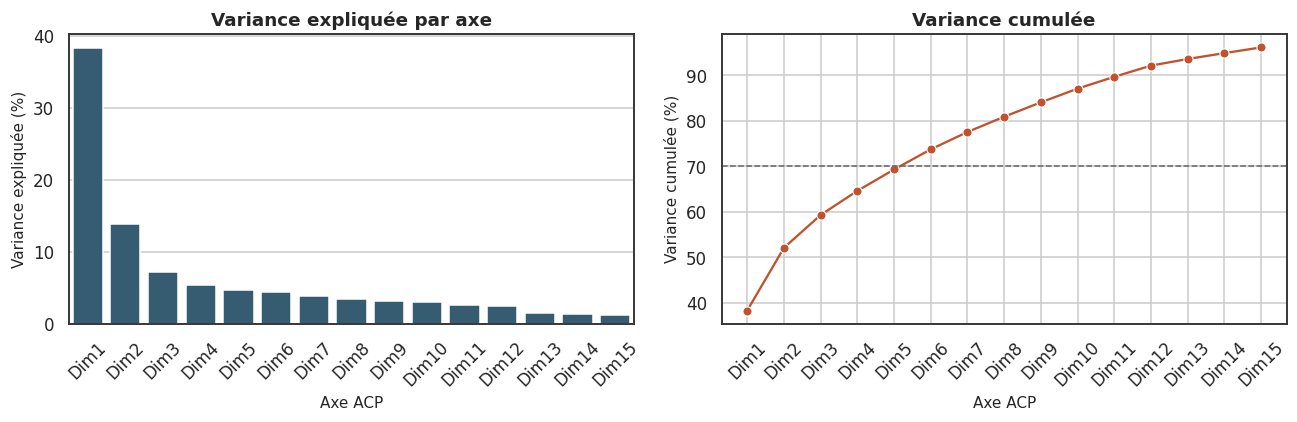

In [54]:
# ===========================================================================
#  SECTION 5 (Cellule 12) — VISUALISATION DE LA VARIANCE EXPLIQUÉE
# ===========================================================================

fig, axes_plot = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=valeurs_propres.head(15), x="axe", y="variance_expliquee_pct", color=COULEUR_PRINCIPALE, ax=axes_plot[0])
axes_plot[0].set_title("Variance expliquée par axe")
axes_plot[0].set_xlabel("Axe ACP")
axes_plot[0].set_ylabel("Variance expliquée (%)")
axes_plot[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=valeurs_propres.head(15), x="axe", y="variance_cumulee_pct", marker="o", color=COULEUR_ACCENT, ax=axes_plot[1])
axes_plot[1].axhline(70, linestyle="--", color="#666666", linewidth=1)
axes_plot[1].set_title("Variance cumulée")
axes_plot[1].set_xlabel("Axe ACP")
axes_plot[1].set_ylabel("Variance cumulée (%)")
axes_plot[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_acp_variance_expliquee.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 6 (Cellule 13) — Coordonnées, contributions et cos² des variables


In [55]:
# ===========================================================================
#  SECTION 6 (Cellule 14) — COORDONNÉES, CONTRIBUTIONS ET COS²
# ===========================================================================

print("=" * 65)
print("  SECTION 6 — VARIABLES ACP")
print("=" * 65)

# Coordonnées des variables = vecteur propre × √valeur propre (coordonnées de
# corrélation : entre -1 et 1 sur données standardisées)
coord_var = pca.components_.T * np.sqrt(pca.explained_variance_)
coord_var_df = pd.DataFrame(coord_var, index=vars_acp, columns=axes).reset_index().rename(columns={"index": "variable"})

# Contribution de chaque variable à un axe = coordonnée²/valeur propre.
contrib_var = (coord_var ** 2) / pca.explained_variance_
contrib_var = contrib_var / contrib_var.sum(axis=0) * 100
contrib_var_df = pd.DataFrame(contrib_var, index=vars_acp, columns=axes).reset_index().rename(columns={"index": "variable"})

# cos² : qualité de représentation
cos2_var = coord_var ** 2
cos2_var = cos2_var / cos2_var.sum(axis=1, keepdims=True)
cos2_var_df = pd.DataFrame(cos2_var, index=vars_acp, columns=axes).reset_index().rename(columns={"index": "variable"})

# Affichage des coordonnées (extrait des 10 premières variables)
print("\n📌 Coordonnées des variables (extrait) :")
display(coord_var_df.head(10).round(3))

# Affichage des cos² (extrait des 10 premières variables)
print("\n📌 Cos² des variables (extrait) :")
display(cos2_var_df.head(10).round(3))

# Affichage des contributions (top 15 sur chaque axe)
print("\n📌 Top contributions sur Dim1 :")
display(contrib_var_df[["variable", "Dim1"]].sort_values("Dim1", ascending=False).head(15).round(3))

if "Dim2" in contrib_var_df.columns:
    print("📌 Top contributions sur Dim2 :")
    display(contrib_var_df[["variable", "Dim2"]].sort_values("Dim2", ascending=False).head(15).round(3))

  SECTION 6 — VARIABLES ACP

📌 Coordonnées des variables (extrait) :


,variable,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,Dim11,Dim12,Dim13,Dim14,Dim15,Dim16,Dim17,Dim18,Dim19,Dim20,Dim21,Dim22,Dim23,Dim24
0,brh_maison_de_transfert,0.884,-0.291,0.061,-0.021,-0.037,-0.013,0.043,-0.064,-0.006,-0.047,0.023,-0.055,0.126,-0.019,-0.070,-0.022,0.032,0.248,0.187,0.060,0.005,0.011,0.028,0.000
1,brh_agent_non_bancaire,0.831,-0.390,0.169,-0.058,-0.057,0.019,0.024,-0.079,0.074,-0.000,0.074,-0.078,0.263,0.017,0.067,0.034,-0.005,-0.102,-0.118,-0.053,-0.008,0.001,0.062,0.000
2,brh_banque,0.860,-0.253,-0.244,0.007,0.021,-0.034,0.013,0.058,-0.002,0.067,-0.024,-0.204,-0.168,-0.016,-0.056,0.126,0.081,-0.044,0.018,-0.080,0.148,0.086,-0.002,0.000
3,brh_atm,0.833,-0.212,-0.271,0.012,0.062,-0.105,0.034,-0.003,0.007,0.107,-0.096,-0.145,-0.155,-0.039,-0.083,0.279,0.056,0.027,-0.051,0.050,-0.115,-0.067,-0.000,0.000
4,brh_microfinance,0.836,-0.337,0.065,-0.046,-0.078,0.051,0.046,0.125,0.020,-0.086,-0.028,-0.126,-0.180,-0.033,-0.076,-0.220,-0.078,-0.097,0.089,-0.129,-0.101,-0.007,-0.000,-0.000
5,brh_caisse_populaire,0.592,-0.283,0.156,0.168,-0.169,0.235,-0.303,-0.032,0.023,-0.027,-0.021,0.548,-0.082,0.130,-0.025,0.099,0.047,0.052,-0.007,-0.078,-0.014,0.012,-0.001,-0.000
6,population_totale,0.739,-0.445,0.177,0.205,0.185,0.010,0.288,0.064,-0.056,0.037,-0.088,0.090,0.185,-0.053,-0.079,-0.028,-0.011,-0.019,-0.039,0.019,0.009,0.006,-0.040,0.001
7,superficie_km2,0.141,-0.229,0.871,0.027,0.030,0.102,0.387,0.024,-0.047,0.018,-0.014,-0.054,-0.029,0.033,-0.006,0.051,0.048,0.012,-0.023,0.009,0.007,0.001,-0.020,-0.001
8,superficie_urbaine_km2,0.753,-0.144,-0.047,0.052,0.242,-0.303,0.085,0.093,-0.017,0.126,-0.046,0.103,-0.097,0.062,0.449,-0.034,-0.023,0.014,0.036,0.013,0.002,-0.010,-0.001,0.000
9,taux_compte_formel,-0.519,-0.298,-0.005,0.071,-0.123,-0.421,0.201,-0.005,0.583,-0.084,-0.011,0.066,-0.011,0.140,-0.077,0.083,-0.161,-0.009,0.029,0.001,0.010,0.013,-0.001,0.000



📌 Cos² des variables (extrait) :


,variable,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,Dim11,Dim12,Dim13,Dim14,Dim15,Dim16,Dim17,Dim18,Dim19,Dim20,Dim21,Dim22,Dim23,Dim24
0,brh_maison_de_transfert,0.776,0.084,0.004,0.000,0.001,0.000,0.002,0.004,0.000,0.002,0.001,0.003,0.016,0.000,0.005,0.000,0.001,0.061,0.035,0.004,0.000,0.000,0.001,0.0
1,brh_agent_non_bancaire,0.685,0.151,0.028,0.003,0.003,0.000,0.001,0.006,0.005,0.000,0.005,0.006,0.069,0.000,0.005,0.001,0.000,0.010,0.014,0.003,0.000,0.000,0.004,0.0
2,brh_banque,0.735,0.063,0.059,0.000,0.000,0.001,0.000,0.003,0.000,0.004,0.001,0.041,0.028,0.000,0.003,0.016,0.006,0.002,0.000,0.006,0.022,0.007,0.000,0.0
3,brh_atm,0.689,0.045,0.073,0.000,0.004,0.011,0.001,0.000,0.000,0.011,0.009,0.021,0.024,0.001,0.007,0.078,0.003,0.001,0.003,0.002,0.013,0.005,0.000,0.0
4,brh_microfinance,0.694,0.113,0.004,0.002,0.006,0.003,0.002,0.015,0.000,0.007,0.001,0.016,0.032,0.001,0.006,0.048,0.006,0.009,0.008,0.017,0.010,0.000,0.000,0.0
5,brh_caisse_populaire,0.348,0.079,0.024,0.028,0.029,0.055,0.091,0.001,0.001,0.001,0.000,0.298,0.007,0.017,0.001,0.010,0.002,0.003,0.000,0.006,0.000,0.000,0.000,0.0
6,population_totale,0.542,0.196,0.031,0.042,0.034,0.000,0.083,0.004,0.003,0.001,0.008,0.008,0.034,0.003,0.006,0.001,0.000,0.000,0.001,0.000,0.000,0.000,0.002,0.0
7,superficie_km2,0.020,0.052,0.753,0.001,0.001,0.010,0.149,0.001,0.002,0.000,0.000,0.003,0.001,0.001,0.000,0.003,0.002,0.000,0.001,0.000,0.000,0.000,0.000,0.0
8,superficie_urbaine_km2,0.564,0.021,0.002,0.003,0.058,0.091,0.007,0.009,0.000,0.016,0.002,0.011,0.009,0.004,0.201,0.001,0.001,0.000,0.001,0.000,0.000,0.000,0.000,0.0
9,taux_compte_formel,0.268,0.088,0.000,0.005,0.015,0.176,0.040,0.000,0.337,0.007,0.000,0.004,0.000,0.019,0.006,0.007,0.026,0.000,0.001,0.000,0.000,0.000,0.000,0.0



📌 Top contributions sur Dim1 :


,variable,Dim1
0,brh_maison_de_transfert,8.444
2,brh_banque,7.997
22,nb_types_services,7.884
4,brh_microfinance,7.553
3,brh_atm,7.500
1,brh_agent_non_bancaire,7.455
8,superficie_urbaine_km2,6.134
19,part_urbaine,6.013
6,population_totale,5.904
21,densite_bancaire_10k,4.987


📌 Top contributions sur Dim2 :


,variable,Dim2
17,taux_internet,15.766
15,taux_epargne_formelle,13.918
10,taux_compte_mobile,11.272
11,taux_utilisation_OTA,8.313
19,part_urbaine,7.074
16,taux_telephone_mobile,7.024
6,population_totale,5.931
12,score_connaissance_fka,5.237
1,brh_agent_non_bancaire,4.565
4,brh_microfinance,3.405


---
## Section 7 (Cellule 15) — Cercle des corrélations et plan factoriel


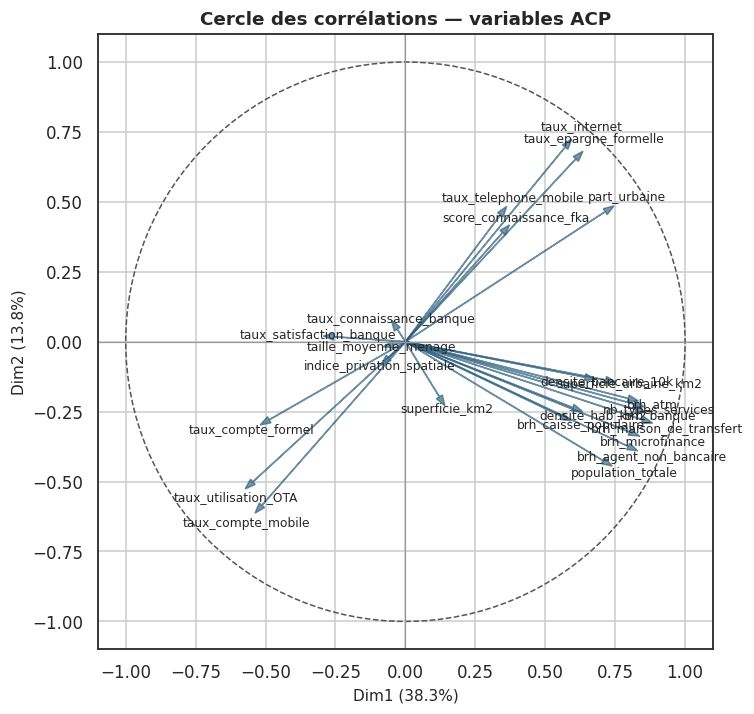

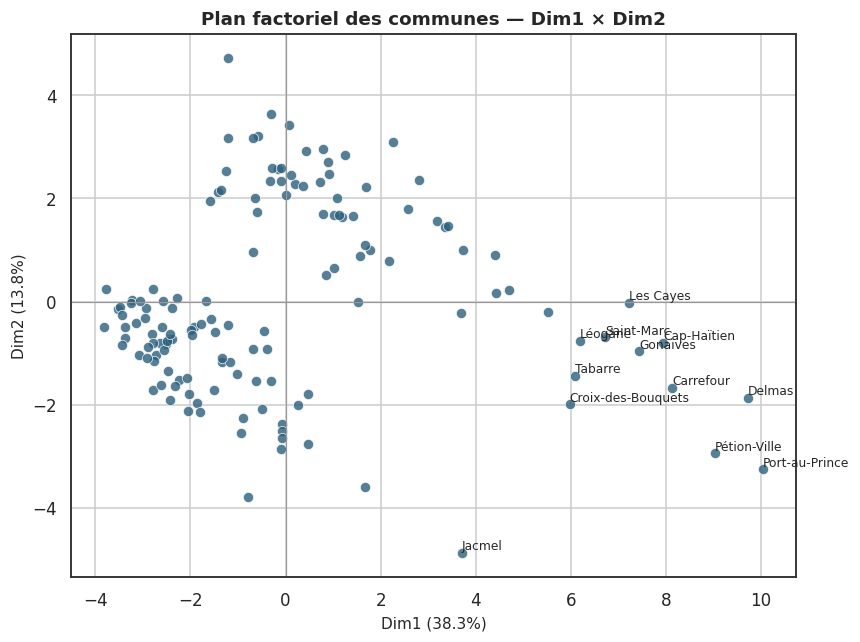

In [56]:
# ===========================================================================
#  SECTION 7 (Cellule 16) — VISUALISATIONS FACTORIELLES
# ===========================================================================

if pca.n_components_ >= 2:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.axhline(0, color="#999999", linewidth=0.8)
    ax.axvline(0, color="#999999", linewidth=0.8)
    ax.add_artist(plt.Circle((0, 0), 1, fill=False, color="#555555", linestyle="--", linewidth=1))

    coords = coord_var_df.set_index("variable")
    for var in vars_acp:
        x, y = coords.loc[var, "Dim1"], coords.loc[var, "Dim2"]
        ax.arrow(0, 0, x, y, color=COULEUR_PRINCIPALE, alpha=0.65, head_width=0.025, length_includes_head=True)
        ax.text(x * 1.06, y * 1.06, var, fontsize=8, ha="center", va="center")

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Dim1 ({valeurs_propres.loc[0, 'variance_expliquee_pct']:.1f}%)")
    ax.set_ylabel(f"Dim2 ({valeurs_propres.loc[1, 'variance_expliquee_pct']:.1f}%)")
    ax.set_title("Cercle des corrélations — variables ACP")
    plt.tight_layout()
    fig.savefig(DOSSIER_FIGURES / "G10_acp_cercle_correlations.png", dpi=300, bbox_inches="tight")
    plt.show()

    scores_plot = pd.DataFrame(coord_ind[:, :2], columns=["Dim1", "Dim2"])
    for c in cols_id:
        scores_plot[c] = matrice_acp[c].values

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=scores_plot, x="Dim1", y="Dim2", color=COULEUR_PRINCIPALE, s=45, alpha=0.8, ax=ax)
    ax.axhline(0, color="#999999", linewidth=0.8)
    ax.axvline(0, color="#999999", linewidth=0.8)
    ax.set_title("Plan factoriel des communes — Dim1 × Dim2")
    ax.set_xlabel(f"Dim1 ({valeurs_propres.loc[0, 'variance_expliquee_pct']:.1f}%)")
    ax.set_ylabel(f"Dim2 ({valeurs_propres.loc[1, 'variance_expliquee_pct']:.1f}%)")

    if "nom_commune" in scores_plot.columns:
        scores_plot["distance_origine"] = np.sqrt(scores_plot["Dim1"]**2 + scores_plot["Dim2"]**2)
        for _, row in scores_plot.nlargest(12, "distance_origine").iterrows():
            ax.text(row["Dim1"], row["Dim2"], row["nom_commune"], fontsize=8, ha="left", va="bottom")

    plt.tight_layout()
    fig.savefig(DOSSIER_FIGURES / "G10_acp_plan_communes.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Une seule composante disponible : visualisation Dim1-Dim2 non produite.")


---
## Section 8 (Cellule 17) — Scores ACP des communes


In [57]:
# ===========================================================================
#  SECTION 8 (Cellule 18) — SCORES ACP DES COMMUNES
# ===========================================================================

scores_communes = pd.concat(
    [matrice_acp[cols_id].reset_index(drop=True), pd.DataFrame(coord_ind, columns=axes)],
    axis=1
)

display(scores_communes.head())

if "nom_commune" in scores_communes.columns:
    print("Communes les plus élevées sur Dim1 :")
    display(scores_communes.sort_values("Dim1", ascending=False)[cols_id + ["Dim1"]].head(10))
    print("Communes les plus faibles sur Dim1 :")
    display(scores_communes.sort_values("Dim1", ascending=True)[cols_id + ["Dim1"]].head(10))


,id_commune,nom_commune,arrondissement,adm2_pcode,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,Dim11,Dim12,Dim13,Dim14,Dim15,Dim16,Dim17,Dim18,Dim19,Dim20,Dim21,Dim22,Dim23,Dim24
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,-3.258678,-4.131774,0.602384,0.226182,-1.316938,0.418964,0.190782,-0.157671,-0.191331,-1.392276,1.217274,0.129152,-0.689523,-0.960843,0.694289,-0.447500,0.004746,-0.408963,-1.007573,-0.299944,-0.338032,0.065582,-0.000668
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,-1.867859,-4.137420,0.722036,0.688011,-1.632219,-0.380631,-0.775346,0.694461,0.130771,-0.455626,-0.727098,0.200430,-0.298407,-0.346418,1.165644,0.194624,-0.304230,0.217993,0.043117,-0.460083,0.066301,-0.066787,-0.004169
2,C-003,Cité Soleil,Port-au-Prince,HT0117,4.425251,0.169995,-2.679387,2.486033,2.501844,-1.677778,-1.483762,1.517718,0.655877,0.463044,-0.428111,0.951181,0.818954,-0.368135,-0.077785,-1.753657,-0.687783,-0.461989,-0.502876,0.589974,0.519956,-0.006070,0.080325,-0.009610
3,C-004,Tabarre,Port-au-Prince,HT0118,6.085279,-1.441390,-3.198570,1.697963,0.437371,-1.398396,-1.670498,-0.533374,1.695990,0.782415,-0.349928,-1.313935,0.083807,0.080813,0.639291,0.044807,-0.187743,0.170870,0.044783,0.641517,-0.060383,0.082794,-0.056555,-0.005198
4,C-005,Carrefour,Port-au-Prince,HT0113,8.132313,-1.670765,-1.522907,0.790299,-0.374735,-1.560038,1.408101,0.457491,-0.640560,-0.245391,0.717915,-0.893506,0.294757,-0.164722,-0.126084,0.172595,0.264843,0.538444,0.231931,0.025758,0.379649,-0.406959,-0.058684,0.004236


Communes les plus élevées sur Dim1 :


,id_commune,nom_commune,arrondissement,adm2_pcode,Dim1
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956
5,C-006,Pétion-Ville,Port-au-Prince,HT0114,9.027931
4,C-005,Carrefour,Port-au-Prince,HT0113,8.132313
30,C-031,Cap-Haïtien,Cap-Haïtien,HT0311,7.943705
62,C-063,Gonaïves,Gonaïves,HT0511,7.440713
89,C-090,Les Cayes,Les Cayes,HT0711,7.217309
68,C-069,Saint-Marc,Saint-Marc,HT0531,6.727622
8,C-009,Léogâne,Léogâne,HT0121,6.188037
3,C-004,Tabarre,Port-au-Prince,HT0118,6.085279


Communes les plus faibles sur Dim1 :


,id_commune,nom_commune,arrondissement,adm2_pcode,Dim1
109,C-110,Bonbon,Jérémie,HT0813,-3.812141
27,C-028,Grand-Gosier,Belle-Anse,HT0232,-3.767593
40,C-041,Ranquitte,Saint-Raphaël,HT0343,-3.532281
53,C-054,Capotille,Ouanaminthe,HT0422,-3.477910
110,C-111,Moron,Jérémie,HT0814,-3.440945
73,C-074,Grande-Saline,Dessalines,HT0543,-3.431271
97,C-098,Arniquet,Port-Salut,HT0723,-3.382141
43,C-044,Borgne,Borgne,HT0351,-3.373333
59,C-060,Vallières,Vallières,HT0441,-3.253305
56,C-057,Sainte-Suzanne,Trou-du-Nord,HT0432,-3.219491


---
## Section 9 (Cellule 19) — Construction de l’IIFT

Le signe d’un axe ACP est arbitraire. L’axe 1 est donc orienté automatiquement pour que les variables positives d’inclusion financière correspondent à un IIFT plus élevé.


In [58]:
# ===========================================================================
#  SECTION 9 (Cellule 20) — CALCUL DE L'IIFT
# ===========================================================================

print("=" * 65)
print("  SECTION 9 — CONSTRUCTION DE L'IIFT")
print("=" * 65)

MOTS_CLES_POSITIFS = [
    "brh_", "banque", "atm", "microfinance", "caisse", "transfert", "agent",
    "densite_bancaire", "taux_compte", "taux_utilisation_OTA", "score_connaissance",
    "taux_connaissance", "taux_satisfaction", "taux_epargne", "telephone", "internet",
    "nb_types_services",
]
MOTS_CLES_NEGATIFS = ["pauvrete", "privation"]

def contient_mot_cle(variable, mots_cles):
    v = variable.lower()
    return any(mot.lower() in v for mot in mots_cles)

coord_dim1 = coord_var_df.set_index("variable")["Dim1"]
variables_ancrage_pos = [v for v in vars_acp if contient_mot_cle(v, MOTS_CLES_POSITIFS)]
variables_ancrage_neg = [v for v in vars_acp if contient_mot_cle(v, MOTS_CLES_NEGATIFS)]

score_orientation = 0.0
if variables_ancrage_pos:
    score_orientation += coord_dim1.loc[variables_ancrage_pos].mean()
if variables_ancrage_neg:
    score_orientation -= coord_dim1.loc[variables_ancrage_neg].mean()

if not variables_ancrage_pos and not variables_ancrage_neg:
    print("⚠️ Aucune variable d'ancrage (positive ou négative) trouvée dans MOTS_CLES_POSITIFS/"
          "NEGATIFS — l'orientation de Dim1 ne peut pas être vérifiée automatiquement et reste "
          "arbitraire (signe +1 par défaut). Vérifiez manuellement le sens de l'IIFT avant de "
          "poursuivre (cf. Top/Bottom communes ci-dessous).")

signe_iift = 1 if score_orientation >= 0 else -1
scores_iift_brut = signe_iift * scores_communes["Dim1"]
iift_0_100 = MinMaxScaler(feature_range=(0, 100)).fit_transform(scores_iift_brut.to_numpy().reshape(-1, 1)).ravel()

labels_iift = ["Très faible", "Faible", "Moyen", "Élevé", "Très élevé"]
try:
    classe_iift = pd.qcut(iift_0_100, q=5, labels=labels_iift, duplicates="drop")
except ValueError:
    classe_iift = pd.cut(iift_0_100, bins=5, labels=labels_iift, include_lowest=True)

iift_communes = matrice_acp[cols_id].copy()
iift_communes["score_acp_dim1_oriente"] = scores_iift_brut
iift_communes["IIFT"] = iift_0_100
iift_communes["classe_IIFT"] = classe_iift.astype(str)

dictionnaire_IIFT = pd.DataFrame([
    {
        "variable": "IIFT",
        "type": "Indice synthétique continu",
        "echelle": "0-100",
        "interpretation": "Plus la valeur est élevée, plus l'inclusion financière territoriale est forte relativement aux communes étudiées.",
        "methode": "Score ACP Dim1 orienté selon les variables positives/négatives, puis normalisation min-max 0-100.",
    },
    {
        "variable": "classe_IIFT",
        "type": "Classe ordinale",
        "echelle": "Très faible à Très élevé",
        "interpretation": "Classe de positionnement relatif de la commune selon l'IIFT.",
        "methode": "Découpage de l'IIFT en cinq classes par quantiles lorsque possible.",
    },
    {
        "variable": "score_acp_dim1_oriente",
        "type": "Score factoriel brut",
        "echelle": "Score ACP non borné",
        "interpretation": "Score de la commune sur le premier axe ACP après orientation du signe.",
        "methode": "Dim1 multiplié par +1 ou -1 afin que les variables positives d'inclusion augmentent avec le score.",
    },
])
# Note : la ligne pour 'IIFT_multi_axes_robustesse' est ajoutée après la Section 11
# (elle dépend de n_axes_robustesse, calculé plus loin dans le notebook).

print(f"Variables d'ancrage positives ({len(variables_ancrage_pos)}) : {variables_ancrage_pos}")
print(f"Variables d'ancrage négatives ({len(variables_ancrage_neg)}) : {variables_ancrage_neg}")
print(f"Score d'orientation Dim1 : {score_orientation:.4f}")
print(f"Signe appliqué à Dim1 : {signe_iift}")

display(iift_communes["IIFT"].describe().round(2))
display(iift_communes["classe_IIFT"].value_counts().sort_index().rename("effectif"))
print("Top 15 communes selon l'IIFT :")
display(iift_communes.sort_values("IIFT", ascending=False).head(15))


  SECTION 9 — CONSTRUCTION DE L'IIFT
Variables d'ancrage positives (17) : ['brh_maison_de_transfert', 'brh_agent_non_bancaire', 'brh_banque', 'brh_atm', 'brh_microfinance', 'brh_caisse_populaire', 'taux_compte_formel', 'taux_compte_mobile', 'taux_utilisation_OTA', 'score_connaissance_fka', 'taux_connaissance_banque', 'taux_satisfaction_banque', 'taux_epargne_formelle', 'taux_telephone_mobile', 'taux_internet', 'densite_bancaire_10k', 'nb_types_services']
Variables d'ancrage négatives (1) : ['indice_privation_spatiale']
Score d'orientation Dim1 : 0.4613
Signe appliqué à Dim1 : 1


,IIFT
count,140.00
mean,27.52
std,21.96
min,0.00
25%,10.22
50%,22.96
75%,35.39
max,100.00


,effectif
classe_IIFT,
Faible,28
Moyen,28
Très faible,28
Très élevé,28
Élevé,28


Top 15 communes selon l'IIFT :


,id_commune,nom_commune,arrondissement,adm2_pcode,score_acp_dim1_oriente,IIFT,classe_IIFT
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,100.000000,Très élevé
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,97.736443,Très élevé
5,C-006,Pétion-Ville,Port-au-Prince,HT0114,9.027931,92.683450,Très élevé
4,C-005,Carrefour,Port-au-Prince,HT0113,8.132313,86.218616,Très élevé
30,C-031,Cap-Haïtien,Cap-Haïtien,HT0311,7.943705,84.857185,Très élevé
62,C-063,Gonaïves,Gonaïves,HT0511,7.440713,81.226439,Très élevé
89,C-090,Les Cayes,Les Cayes,HT0711,7.217309,79.613846,Très élevé
68,C-069,Saint-Marc,Saint-Marc,HT0531,6.727622,76.079138,Très élevé
8,C-009,Léogâne,Léogâne,HT0121,6.188037,72.184257,Très élevé
3,C-004,Tabarre,Port-au-Prince,HT0118,6.085279,71.442514,Très élevé


---
## Section 10 (Cellule 21) — Visualisation de l’IIFT


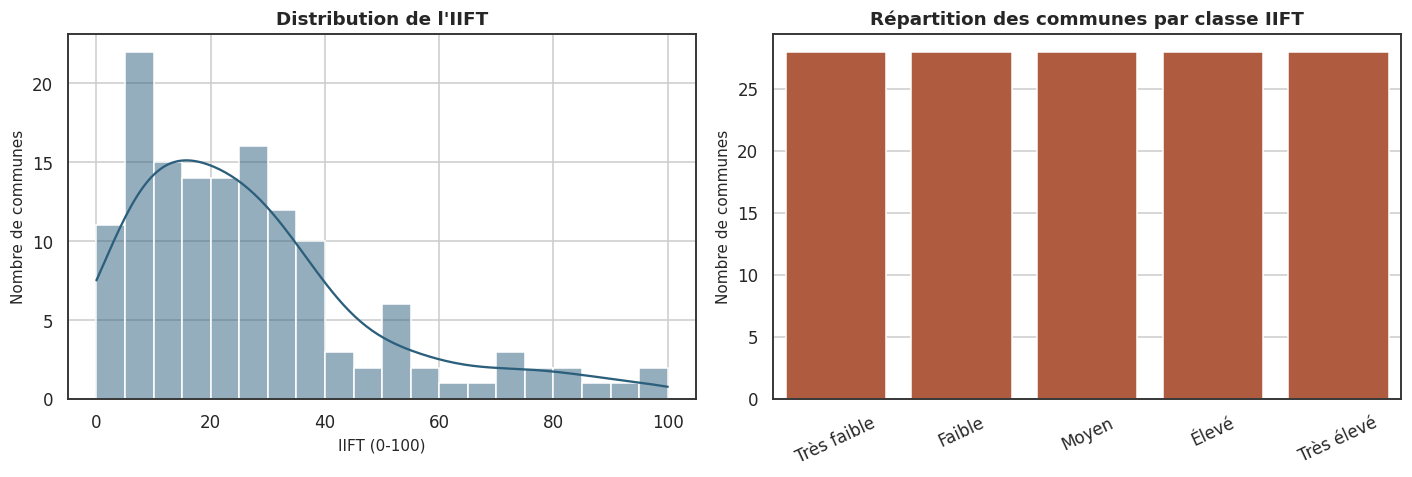

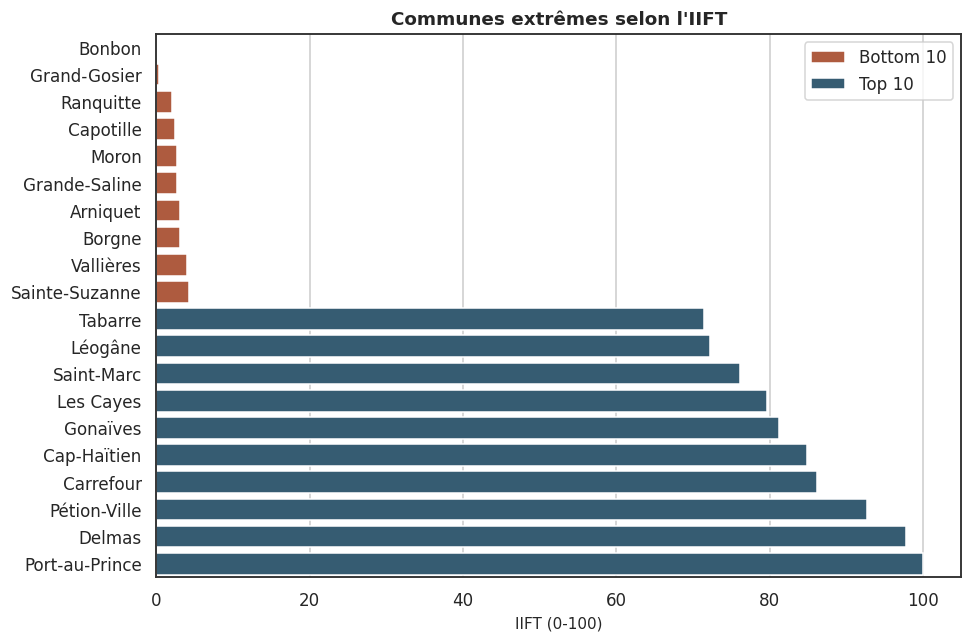

In [59]:
# ===========================================================================
#  SECTION 10 (Cellule 22) — VISUALISATIONS IIFT
# ===========================================================================

fig, axes_plot = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(iift_communes["IIFT"], bins=20, kde=True, color=COULEUR_PRINCIPALE, ax=axes_plot[0])
axes_plot[0].set_title("Distribution de l'IIFT")
axes_plot[0].set_xlabel("IIFT (0-100)")
axes_plot[0].set_ylabel("Nombre de communes")

ordre_classes = ["Très faible", "Faible", "Moyen", "Élevé", "Très élevé"]
classe_counts = iift_communes["classe_IIFT"].value_counts().reindex(ordre_classes)
sns.barplot(x=classe_counts.index, y=classe_counts.values, color=COULEUR_ACCENT, ax=axes_plot[1])
axes_plot[1].set_title("Répartition des communes par classe IIFT")
axes_plot[1].set_xlabel("")
axes_plot[1].set_ylabel("Nombre de communes")
axes_plot[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_iift_distribution_classes.png", dpi=300, bbox_inches="tight")
plt.show()

if "nom_commune" in iift_communes.columns:
    top_bottom = pd.concat([
        iift_communes.nlargest(10, "IIFT").assign(groupe="Top 10"),
        iift_communes.nsmallest(10, "IIFT").assign(groupe="Bottom 10"),
    ])
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(
        data=top_bottom.sort_values("IIFT"), x="IIFT", y="nom_commune", hue="groupe",
        palette={"Top 10": COULEUR_PRINCIPALE, "Bottom 10": COULEUR_ACCENT}, ax=ax
    )
    ax.set_title("Communes extrêmes selon l'IIFT")
    ax.set_xlabel("IIFT (0-100)")
    ax.set_ylabel("")
    ax.legend(title="")
    plt.tight_layout()
    fig.savefig(DOSSIER_FIGURES / "G10_iift_top_bottom_communes.png", dpi=300, bbox_inches="tight")
    plt.show()


---
## Section 11 (Cellule 23) — Analyse de robustesse multi-axes

Cette variante est un contrôle méthodologique. L’IIFT principal reste celui fondé sur Dim1 orienté, sauf décision contraire dans le rapport.


  SECTION 11 — ROBUSTESSE MULTI-AXES
Axes utilisés : ['Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5', 'Dim6']
Poids des axes : {'Dim1': np.float64(0.519), 'Dim2': np.float64(0.187), 'Dim3': np.float64(0.098), 'Dim4': np.float64(0.072), 'Dim5': np.float64(0.064), 'Dim6': np.float64(0.06)}
Corrélation IIFT principal vs variante multi-axes : 0.908


,axe,score_orientation,signe
0,Dim1,0.461,1
1,Dim2,0.015,1
2,Dim3,-0.199,-1
3,Dim4,0.041,1
4,Dim5,-0.865,-1
5,Dim6,-0.220,-1


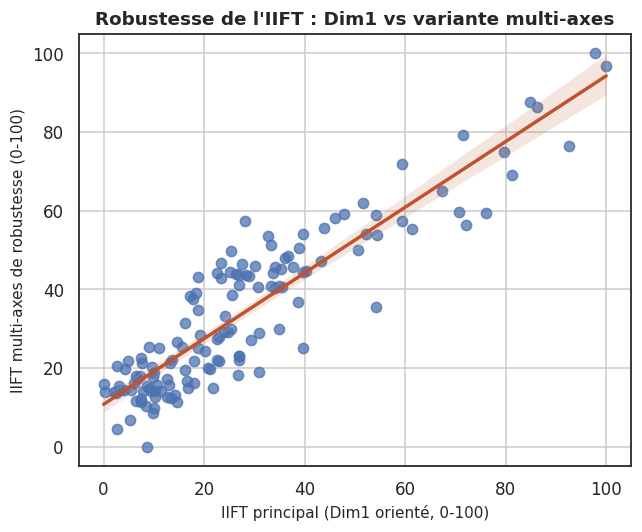

In [60]:
# ===========================================================================
#  SECTION 11 (Cellule 24) — ROBUSTESSE : VARIANTE MULTI-AXES
# ===========================================================================

print("=" * 65)
print("  SECTION 11 — ROBUSTESSE MULTI-AXES")
print("=" * 65)

n_axes_robustesse = n_axes_70
axes_robustesse = axes[:n_axes_robustesse]
poids_axes = pca.explained_variance_ratio_[:n_axes_robustesse]
poids_axes = poids_axes / poids_axes.sum()

coord_vars = coord_var_df.set_index("variable")
scores_orientes = []
orientation_axes = []

for axe in axes_robustesse:
    score_orientation_axe = 0.0
    if variables_ancrage_pos:
        score_orientation_axe += coord_vars.loc[variables_ancrage_pos, axe].mean()
    if variables_ancrage_neg:
        score_orientation_axe -= coord_vars.loc[variables_ancrage_neg, axe].mean()
    signe_axe = 1 if score_orientation_axe >= 0 else -1
    # Standardisation (z-score) de l'axe AVANT pondération : chaque axe ACP a
    # nativement un écart-type proportionnel à √valeur_propre, donc Dim1 domine
    # déjà l'échelle brute. Sans ce z-score, la pondération par variance
    # amplifierait cette domination une seconde fois, rendant la variante
    # multi-axes quasi identique à Dim1 seul (test de robustesse non probant).
    score_axe = scores_communes[axe].to_numpy()
    score_axe_standardise = (score_axe - score_axe.mean()) / score_axe.std()
    scores_orientes.append(signe_axe * score_axe_standardise)
    orientation_axes.append({"axe": axe, "score_orientation": score_orientation_axe, "signe": signe_axe})

scores_orientes = np.vstack(scores_orientes).T
iift_multi_brut = scores_orientes @ poids_axes
iift_multi_0_100 = MinMaxScaler(feature_range=(0, 100)).fit_transform(iift_multi_brut.reshape(-1, 1)).ravel()
iift_communes["IIFT_multi_axes_robustesse"] = iift_multi_0_100

dictionnaire_IIFT.loc[len(dictionnaire_IIFT)] = {
    "variable": "IIFT_multi_axes_robustesse",
    "type": "Indice synthétique continu (contrôle de robustesse)",
    "echelle": "0-100",
    "interpretation": "Variante de l'IIFT combinant plusieurs axes ACP pondérés par variance expliquée. "
                       "Sert uniquement à vérifier la stabilité de l'IIFT principal (Dim1) — non retenue "
                       "comme indice de référence sauf décision contraire dans le rapport.",
    "methode": f"Moyenne pondérée (poids = variance expliquée) des {n_axes_robustesse} premiers axes ACP, "
               f"chacun orienté puis standardisé (z-score) avant pondération.",
}

correlation_iift = np.corrcoef(iift_communes["IIFT"], iift_communes["IIFT_multi_axes_robustesse"])[0, 1]
orientation_axes_df = pd.DataFrame(orientation_axes)

print(f"Axes utilisés : {axes_robustesse}")
print(f"Poids des axes : {dict(zip(axes_robustesse, np.round(poids_axes, 3)))}")
print(f"Corrélation IIFT principal vs variante multi-axes : {correlation_iift:.3f}")
display(orientation_axes_df.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(data=iift_communes, x="IIFT", y="IIFT_multi_axes_robustesse", scatter_kws={"alpha": 0.75, "s": 45}, line_kws={"color": COULEUR_ACCENT}, ax=ax)
ax.set_title("Robustesse de l'IIFT : Dim1 vs variante multi-axes")
ax.set_xlabel("IIFT principal (Dim1 orienté, 0-100)")
ax.set_ylabel("IIFT multi-axes de robustesse (0-100)")
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_iift_robustesse_multi_axes.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 12 (Cellule 25) — Exports des résultats ACP et IIFT

Les tables sont enregistrées dans `output/tables/acp_iift_tables/` et les figures HD (300 dpi) dans
`output/figures/`, comme dans le notebook EDA. Un zip des figures est créé et, sous Colab,
toutes les tables (CSV) et le zip de figures sont proposés en téléchargement automatique.
Pour les rendre disponibles sur GitHub, il faudra ensuite les ajouter dans `output/tables/acp_iift_tables`, committer et pousser dans le dépôt.


In [61]:
# ===========================================================================
#  SECTION 12 (Cellule 26) — EXPORTS ACP & IIFT
# ===========================================================================

print("=" * 65)
print("  SECTION 12 — EXPORTS ACP & IIFT")
print("=" * 65)

if "transformation_acp" in dictionnaire_acp.columns:
    transformation_map = dictionnaire_acp.set_index("variable")["transformation_acp"].to_dict()
    for table in [coord_var_df, contrib_var_df, cos2_var_df]:
        if "transformation_acp" not in table.columns:
            table.insert(1, "transformation_acp", table["variable"].map(transformation_map).fillna("non documentée"))

exports = {
    "G10_acp_valeurs_propres.csv": valeurs_propres,
    "G10_acp_coordonnees_variables.csv": coord_var_df,
    "G10_acp_contributions_variables.csv": contrib_var_df,
    "G10_acp_cos2_variables.csv": cos2_var_df,
    "G10_acp_scores_communes.csv": scores_communes,
    "G10_iift_communes.csv": iift_communes,
    "G10_dictionnaire_IIFT.csv": dictionnaire_IIFT,
}

for nom_fichier, table in exports.items():
    chemin = DOSSIER_TABLES / nom_fichier
    table.to_csv(chemin, index=False, encoding="utf-8-sig")
    print(f"✅ {nom_fichier} exporté — {table.shape[0]} lignes × {table.shape[1]} colonnes")

print()
print("✅ Exports terminés dans output/tables/acp_iift_tables")
print("   Aucune matrice d'apprentissage supervisé n'est créée dans ce notebook.")

# ── Export HD (zip) de toutes les figures générées, comme dans le notebook EDA ──
import shutil

fichiers_figures = sorted(DOSSIER_FIGURES.glob("*.png"))
print(f"\n📊 {len(fichiers_figures)} figure(s) HD (300 dpi) trouvée(s) dans '{DOSSIER_FIGURES}/'")

if fichiers_figures:
    chemin_zip_base = "G10_ACP_IIFT_figures_HD"
    chemin_zip = shutil.make_archive(chemin_zip_base, "zip", DOSSIER_FIGURES)
    taille_mo = os.path.getsize(chemin_zip) / (1024 * 1024)
    print(f"✅ {chemin_zip} créé ({taille_mo:.1f} Mo, {len(fichiers_figures)} image(s))")
else:
    chemin_zip = None
    print("⚠️ Aucune figure trouvée — relancez les sections avec graphiques avant cette cellule.")

# ── Téléchargement automatique sous Colab (tables + zip de figures) ────────
if IN_COLAB:
    from google.colab import files
    for nom_fichier in exports:
        files.download(str(DOSSIER_TABLES / nom_fichier))
    if chemin_zip:
        files.download(chemin_zip)
    print("\n✅ Téléchargements Colab lancés (tables CSV + zip de figures)")
else:
    print(f"\nℹ️ Hors Colab : récupérez directement les fichiers dans '{DOSSIER_TABLES}/', "
          f"'{DOSSIER_FIGURES}/'" + (f" (ou le zip '{chemin_zip}')" if chemin_zip else ""))



  SECTION 12 — EXPORTS ACP & IIFT
✅ G10_acp_valeurs_propres.csv exporté — 24 lignes × 4 colonnes
✅ G10_acp_coordonnees_variables.csv exporté — 24 lignes × 26 colonnes
✅ G10_acp_contributions_variables.csv exporté — 24 lignes × 26 colonnes
✅ G10_acp_cos2_variables.csv exporté — 24 lignes × 26 colonnes
✅ G10_acp_scores_communes.csv exporté — 140 lignes × 28 colonnes
✅ G10_iift_communes.csv exporté — 140 lignes × 8 colonnes
✅ G10_dictionnaire_IIFT.csv exporté — 4 lignes × 5 colonnes

✅ Exports terminés dans output/tables/acp_iift_tables
   Aucune matrice d'apprentissage supervisé n'est créée dans ce notebook.

📊 6 figure(s) HD (300 dpi) trouvée(s) dans 'output/figures/'
✅ /content/G10_ACP_IIFT_figures_HD.zip créé (1.3 Mo, 6 image(s))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Téléchargements Colab lancés (tables CSV + zip de figures)


---
## Section 13 (Cellule 27) — Synthèse méthodologique pour le rapport


In [62]:
# ===========================================================================
#  SECTION 13 (Cellule 28) — SYNTHÈSE POUR LE RAPPORT
# ===========================================================================

resume_methodo = f"""
Synthèse méthodologique — ACP & IIFT

1. La matrice ACP utilisée contient {matrice_acp.shape[0]} communes et {len(vars_acp)} variables quantitatives actives.
2. Les variables ont été centrées-réduites avant l'ACP afin de neutraliser les différences d'échelle.
3. L'axe 1 explique {valeurs_propres.loc[0, 'variance_expliquee_pct']:.1f}% de la variance totale.
4. L'IIFT est construit à partir du score de chaque commune sur l'axe 1, après orientation du signe pour que les variables positives d'inclusion financière augmentent avec l'indice.
5. L'IIFT est normalisé sur une échelle 0-100, où 100 représente la position relative la plus favorable parmi les communes étudiées.
6. Une variante multi-axes a été calculée uniquement comme test de robustesse ; elle n'est pas retenue comme indice principal sauf décision méthodologique contraire.
7. L'IIFT sera utilisé comme variable cible synthétique dans la Phase 2.5, sans modélisation supervisée dans ce notebook.
"""

print(resume_methodo)



Synthèse méthodologique — ACP & IIFT

1. La matrice ACP utilisée contient 140 communes et 24 variables quantitatives actives.
2. Les variables ont été centrées-réduites avant l'ACP afin de neutraliser les différences d'échelle.
3. L'axe 1 explique 38.3% de la variance totale.
4. L'IIFT est construit à partir du score de chaque commune sur l'axe 1, après orientation du signe pour que les variables positives d'inclusion financière augmentent avec l'indice.
5. L'IIFT est normalisé sur une échelle 0-100, où 100 représente la position relative la plus favorable parmi les communes étudiées.
6. Une variante multi-axes a été calculée uniquement comme test de robustesse ; elle n'est pas retenue comme indice principal sauf décision méthodologique contraire.
7. L'IIFT sera utilisé comme variable cible synthétique dans la Phase 2.5, sans modélisation supervisée dans ce notebook.

